# Usar Jupyter a Odoo.

> Cerca al repositori d'aquests apunts aquest capítol, que és un notebook de Jupyter, i prova-ho, té codi executable: https://github.com/xxjcaxx/sge_odoo/blob/master/apunts/Jupyter%20y%20Odoo.ipynb

Jupyter és un entorn de programació i documentació integrat. Produeix una pàgina web on es pot programar a Python de forma interactiva i veure'n el resultat.

Veurem com provar Odoo dins de Jupyter per fer tutorials o fer-lo servir a classe.

Odoo quan arrenca estableix un entorn molt complex. Jupyter en principi només està preparat per executar Python “vanilla” i anar incorporant llibreries.

Jupyter es pot instal·lar amb Docker, amb Anaconda o amb pip. En el nostre cas, com estem treballant amb Odoo a `Docker Compose` el més senzill és afegir al fitxer `docker-compose.yml` un servei per a Jupyter.

```yaml 
jupyter: 
    container_name: jupyter 
    image: jupyter/base-notebook 
    ports: 
        - "8888:8888" 
    volums: 
        - ./notebooks:/home/jovyan/work
```

Una altra opció és instal·lar Jupyter al propi contenidor d'Odoo afegint-lo al `Dockerfile`, però és més complicat i no és necessari.


## Amb JSON-2

A partir d'Odoo 19 es fa servir aquesta nova API autodocumentada a /doc que és més fàcil d'utilitzar que JSON-RPC.

La documentació d'aquesta API es pot consultar al capítol Web Controllers d'aquests apunts.



In [9]:
import json
import urllib.request

HOST = 'localhost'
PORT = 8069
DB = 'proves2'
API_KEY = '8256fe38dcf41aeece425577ddae88c56c5fe8d7'

def json_2(url, body):
    print(json.dumps(body).encode())
    req = urllib.request.Request(url=url, data=json.dumps(body).encode(), headers={
        "Content-Type":"application/json",
        "Authorization": "Bearer %s" % API_KEY,
        "X-Odoo-Database": DB
    })
    reply = json.loads(urllib.request.urlopen(req).read().decode('UTF-8'))
    
    return reply


# Test

url = "http://%s:%s/json/2/res.partner/search_read" % (HOST, PORT)
body = {
    "domain": [["display_name","ilike",""]],  # No filtra res
    "fields": [
        "display_name"
    ],
    "limit": 20
}

print(json_2(url, body))

b'{"domain": [["display_name", "ilike", ""]], "fields": ["display_name"], "limit": 20}'
[{'id': 9, 'display_name': 'Acme Corporation'}, {'id': 36, 'display_name': 'Acme Corporation, Addison Olson'}, {'id': 19, 'display_name': 'Acme Corporation, Douglas Fletcher'}, {'id': 20, 'display_name': 'Acme Corporation, Floyd Steward'}, {'id': 46, 'display_name': 'Ayuntamiento De Bilbao'}, {'id': 47, 'display_name': 'Ayuntamiento De Bilbao, Departamento de Contabilidad'}, {'id': 15, 'display_name': 'Azure Interior'}, {'id': 27, 'display_name': 'Azure Interior, Brandon Freeman'}, {'id': 34, 'display_name': 'Azure Interior, Colleen Diaz'}, {'id': 28, 'display_name': 'Azure Interior, Nicole Ford'}, {'id': 43, 'display_name': 'ES Company'}, {'id': 10, 'display_name': 'Gemini Furniture'}, {'id': 21, 'display_name': 'Gemini Furniture, Edwin Hansen'}, {'id': 23, 'display_name': 'Gemini Furniture, Jesse Brown'}, {'id': 32, 'display_name': 'Gemini Furniture, Oscar Morgan'}, {'id': 24, 'display_name': 'Gem

A partir de l'exemple es poden fer consultes més complexes respectant la sintaxi i les rutes que trobem a la documentació: http://localhost:8069/doc/res.partner#search_read 

### Exemple complet

Suposem que volem fer un estudi estadístic de les nostres vendes. Necessitarem consultar `sale.order`, `sale.order.line` entre altres. Guardarem les dades en alguna estructura de dades adequada per a treballar en Jupyter i Python com `Pandas` amés, si volem mostrar gràfics utilitzarem `Matplotlib`, per exemple. Hi ha moltes opcions. 


In [13]:
url = "http://%s:%s/json/2/sale.order/search_read" % (HOST, PORT)
body = {
    "fields": [
        "name", "partner_id", "order_line", "amount_total", "date_order"
    ],
    "limit": 200,
    "order": "date_order"
}

vendes = json_2(url, body)

import pandas as pd

df = pd.DataFrame(vendes)

df

b'{"fields": ["name", "partner_id", "order_line", "amount_total", "date_order"], "limit": 200, "order": "date_order"}'


,id,name,partner_id,order_line,amount_total,date_order
0,18,S00018,"[10, Gemini Furniture]","[38, 39]",831.0,2026-04-17 12:57:31
1,1,S00001,"[9, Acme Corporation]","[1, 2, 3]",1740.0,2026-04-22 12:57:00
2,2,S00002,"[11, Ready Mat]","[4, 5]",2947.5,2026-04-22 12:57:00
3,19,S00019,"[7, YourCompany, Joel Willis]","[40, 41, 42]",1740.0,2026-04-22 12:57:00
4,5,S00005,"[9, Acme Corporation]",[12],405.0,2026-04-22 12:57:00
5,20,S00020,"[7, YourCompany, Joel Willis]","[43, 44]",2947.5,2026-04-22 12:57:31
6,17,S00017,"[10, Gemini Furniture]","[36, 37]",951.0,2026-04-24 12:57:31
7,11,S00011,"[10, Gemini Furniture]","[24, 25]",1096.5,2026-05-01 12:57:31
8,15,S00015,"[10, Gemini Furniture]","[32, 33]",1541.5,2026-05-08 12:57:31
9,9,S00009,"[10, Gemini Furniture]","[20, 21]",654.0,2026-05-15 12:57:31


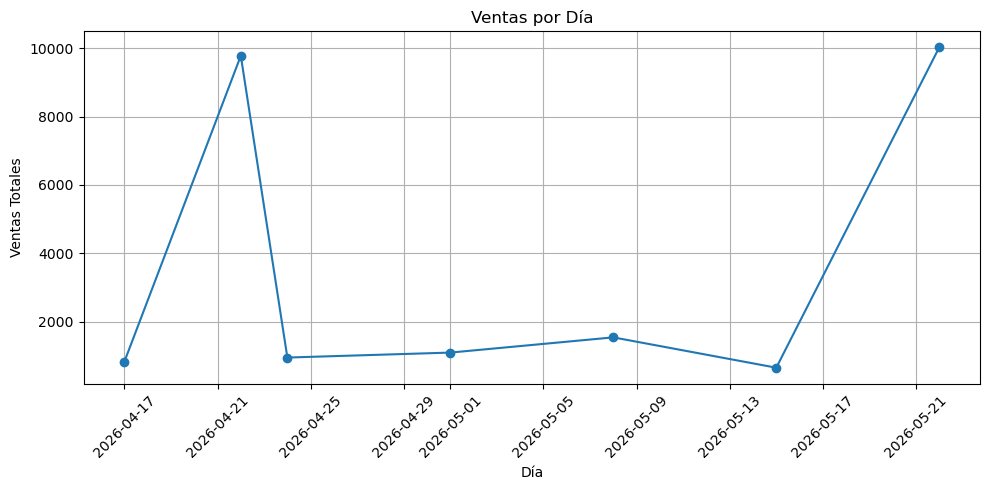

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Convertir a datetime
df['date_order'] = pd.to_datetime(df['date_order'])

# Extraer solo la fecha
df['day'] = df['date_order'].dt.date

# Agrupar por día y sumar ventas
sales_per_day = df.groupby('day')['amount_total'].sum()

# Crear gráfica
plt.figure(figsize=(10, 5))
plt.plot(sales_per_day.index, sales_per_day.values, marker='o')

# Etiquetas
plt.xlabel('Día')
plt.ylabel('Ventas Totales')
plt.title('Ventas por Día')

# Rotar fechas
plt.xticks(rotation=45)

plt.grid(True)
plt.tight_layout()
plt.show()


In [24]:
orderlines = df['order_line'].explode().dropna().unique()

url = "http://%s:%s/json/2/sale.order.line/read" % (HOST, PORT)
body = {
    "ids": orderlines.tolist(),
    "fields": [
        "name", "product_id", "price_unit", "product_uom_qty"
    ]
    
}

linies_venda = json_2(url, body)

df_linies = pd.DataFrame(linies_venda)

df_linies



b'{"ids": [38, 39, 1, 2, 3, 4, 5, 40, 41, 42, 12, 43, 44, 36, 37, 24, 25, 32, 33, 20, 21, 6, 7, 34, 35, 13, 18, 19, 28, 29, 30, 31, 8, 9, 10, 11, 14, 15, 16, 17, 22, 23, 26, 27], "fields": ["name", "product_id", "price_unit", "product_uom_qty"]}'


,id,name,product_id,price_unit,product_uom_qty
0,38,[FURN_6667] Pantallas de bloque acústico (Negr...,"[38, [FURN_6667] Acoustic Bloc Screens (Black)]",295.00,2.0
1,39,[FURN_0269] Silla de oficina negra\nSilla de o...,"[31, [FURN_0269] Office Chair Black]",120.50,2.0
2,1,[FURN_6667] Pantallas de bloque acústico (Negr...,"[38, [FURN_6667] Acoustic Bloc Screens (Black)]",295.00,3.0
3,2,[FURN_8888] Lámpara de oficina,"[6, [FURN_8888] Office Lamp]",145.00,5.0
4,3,[FURN_7777] Silla de oficina\nCómoda silla ama...,"[5, [FURN_7777] Office Chair]",65.00,2.0
5,4,Diseño interior virtual,"[3, Virtual Interior Design]",75.00,24.0
6,5,Área de casa virtual,"[4, Virtual Home Staging]",38.25,30.0
7,40,[FURN_6667] Pantallas de bloque acústico (Negr...,"[38, [FURN_6667] Acoustic Bloc Screens (Black)]",295.00,3.0
8,41,[FURN_8888] Lámpara de oficina,"[6, [FURN_8888] Office Lamp]",145.00,5.0
9,42,[FURN_7777] Silla de oficina\nCómoda silla ama...,"[5, [FURN_7777] Office Chair]",65.00,2.0


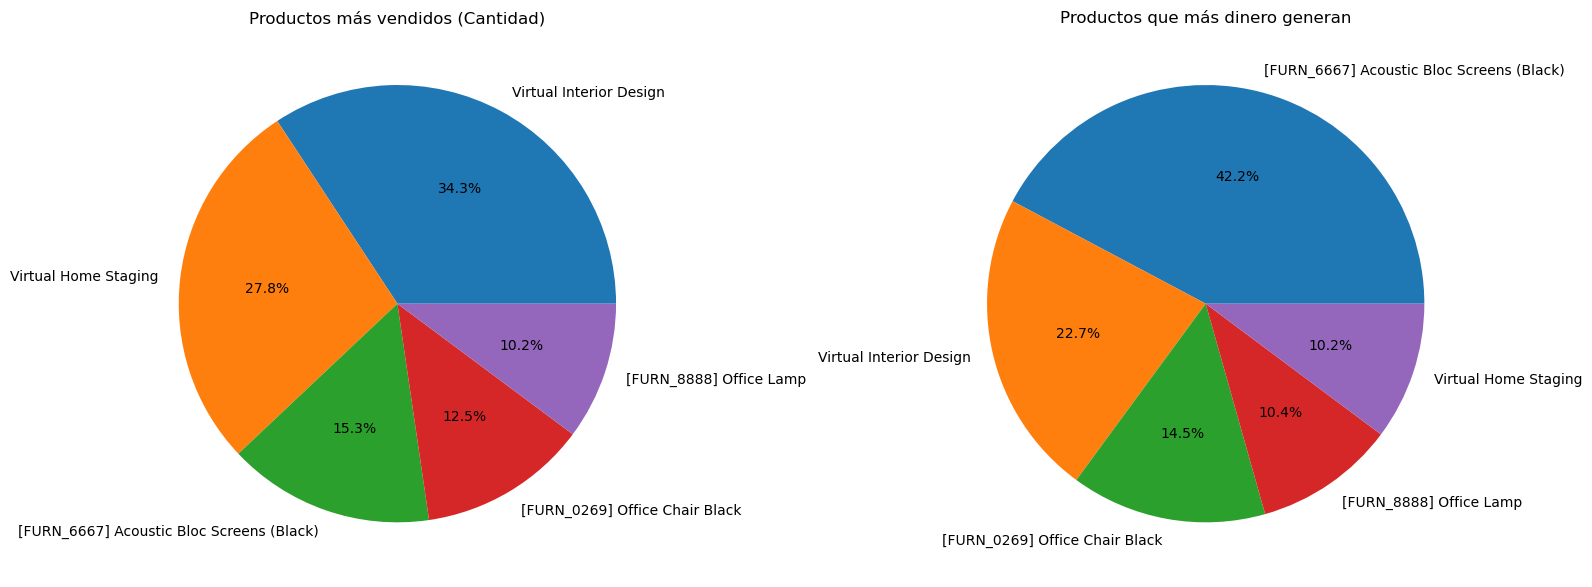

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Extraer nombre del producto
df_linies['product_name'] = df_linies['product_id'].apply(lambda x: x[1])

# -----------------------------
# 1. Productos más vendidos (cantidad)
# -----------------------------
qty_by_product = (
    df_linies.groupby('product_name')['product_uom_qty']
    .sum()
    .sort_values(ascending=False)
)

# -----------------------------
# 2. Productos que más dinero generan
# -----------------------------
df_linies['total_sales'] = df_linies['price_unit'] * df_linies['product_uom_qty']

sales_by_product = (
    df_linies.groupby('product_name')['total_sales']
    .sum()
    .sort_values(ascending=False)
)

# Opcional: Top 5
top_qty = qty_by_product.head(5)
top_sales = sales_by_product.head(5)

# -----------------------------
# Crear figura con 2 gráficas
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Pie 1: Cantidad vendida
axes[0].pie(
    top_qty.values,
    labels=top_qty.index,
    autopct='%1.1f%%'
)
axes[0].set_title('Productos más vendidos (Cantidad)')

# Pie 2: Dinero generado
axes[1].pie(
    top_sales.values,
    labels=top_sales.index,
    autopct='%1.1f%%'
)
axes[1].set_title('Productos que más dinero generan')

plt.tight_layout()
plt.show()

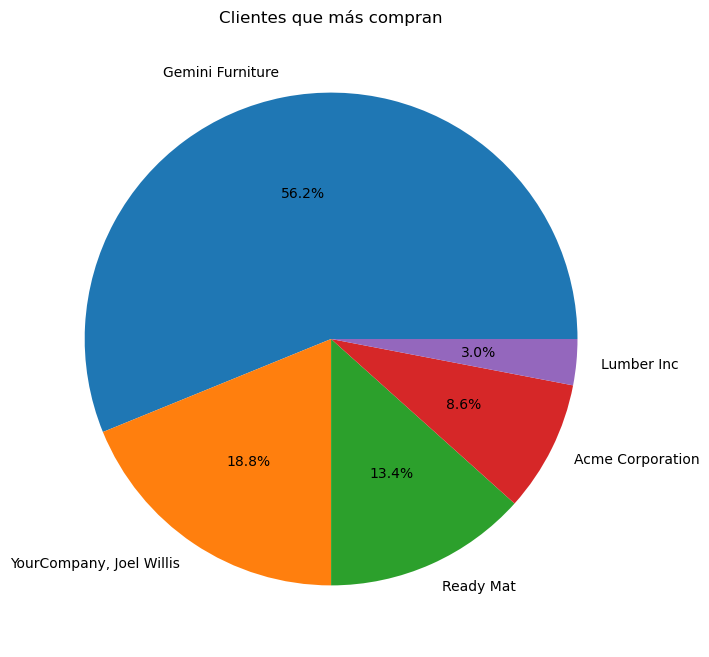

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Extraer nombre del cliente desde partner_id
df['customer'] = df['partner_id'].apply(lambda x: x[1])

# Agrupar por cliente y sumar ventas
sales_by_customer = (
    df.groupby('customer')['amount_total']
    .sum()
    .sort_values(ascending=False)
)

# Opcional: quedarte con los 5 mejores clientes
top_customers = sales_by_customer.head(5)

# Crear gráfica de circunferencia
plt.figure(figsize=(8, 8))

plt.pie(
    top_customers.values,
    labels=top_customers.index,
    autopct='%1.1f%%',
)

plt.title('Clientes que más compran')

plt.show()

## Con JSON-RPC:

> Obsoleto a partir de Odoo 19. 

Odoo también permite acceder diréctamente con JSON. 

Usa https://www.jsonrpc.org/specification :


In [1]:
import json
import random
import urllib.request

HOST = 'localhost'
PORT = 8069
DB = 'roma'
USER = 'admin'
PASS = '1234'

def json_rpc(url, method, params):
    data = {
        "jsonrpc": "2.0",
        "method": method,
        "params": params,
        "id": random.randint(0, 1000000000),
    }
    print(json.dumps(data).encode())
    req = urllib.request.Request(url=url, data=json.dumps(data).encode(), headers={
        "Content-Type":"application/json",
    })
    reply = json.loads(urllib.request.urlopen(req).read().decode('UTF-8'))
    if reply.get("error"):
        raise Exception(reply["error"])
    return reply["result"]

def call(url, service, method, *args):
    return json_rpc(url, "call", {"service": service, "method": method, "args": args})

# log in the given database
url = "http://%s:%s/jsonrpc" % (HOST, PORT)
uid = call(url, "common", "login", DB, USER, PASS)

# create a new note
args = []
clients = call(url, "object", "execute", DB, uid, PASS, 'res.partner', 'search', args)
print(clients)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "common", "method": "login", "args": ["roma", "admin", "1234"]}, "id": 465964370}'
b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "res.partner", "search", []]}, "id": 516884869}'
[14, 26, 33, 27, 10, 35, 18, 19, 41, 11, 20, 22, 31, 23, 15, 34, 12, 21, 25, 37, 24, 36, 30, 38, 13, 29, 28, 9, 17, 32, 16, 1, 39, 40, 8, 7, 3, 68]


Si observamos lo que envía al servidor, es un JSON en un determinado formato. Informa del método "call" y los parámetros como indica el estándar JSON-RPC https://www.jsonrpc.org/specification.

A continuación, en los "params" es donde hay que especificar la petición RPC a Odoo. En el primer ejemplo lo envía al "service" "common" para hacer "login" y les envía los argumentos que el login necesita. 

Aquí podemos encontrar información, aunque sea de XML-RPC: https://www.odoo.com/documentation/14.0/developer/reference/external_api.html 

Después, en el "service" "object" le pedimos que ejecute un método del ORM. En este caso es el método "search". El resto de argumentos lo pasamos en un array, ya que los necesita de forma posicional. 

## Read

En el siguiente ejemplo hacemos lo mismo, pero con el método "read", pero vemos que los argumentos los pasa en el mismo órden que el search anterior: base de datos, uid, password, modelo, método ORM, argumentos, en este caso necesita dos argumentos, un array de ids y los fields que va a tener que leer. 

In [2]:

clients_data = call(url, "object", "execute", DB, uid, PASS, 'res.partner', 'read', [14,26],['name', 'country_id', 'comment'])
print(clients_data)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "res.partner", "read", [14, 26], ["name", "country_id", "comment"]]}, "id": 607030128}'
[{'id': 14, 'name': 'Azure Interior', 'country_id': [233, 'United States'], 'comment': False}, {'id': 26, 'name': 'Brandon Freeman', 'country_id': [233, 'United States'], 'comment': False}]


Veamos ahora un ejemplo para cada función típica del ORM de Odoo:

## Create

In [15]:
new_partner = call(url, "object", "execute", DB, uid, PASS, 'res.partner', 'create', {"name": "pepe"})

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "res.partner", "create", {"name": "pepe"}]}, "id": 281074390}'


In [16]:
print(new_partner)

70


In [17]:
partner_data = call(url, "object", "execute", DB, uid, PASS, 'res.partner', 'read', [new_partner],['name', 'country_id', 'comment'])
print(partner_data)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "res.partner", "read", [70], ["name", "country_id", "comment"]]}, "id": 900418510}'
[{'id': 70, 'name': 'pepe', 'country_id': False, 'comment': False}]


## Write
Para actualizar un registro

In [20]:
call(url, "object", "execute", DB, uid, PASS, 'res.partner', 'write', new_partner, {"name": "pepe2"})

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "res.partner", "write", 70, {"name": "pepe2"}]}, "id": 118774873}'


True

In [21]:
partner_data = call(url, "object", "execute", DB, uid, PASS, 'res.partner', 'read', [new_partner],['name', 'country_id', 'comment'])
print(partner_data)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "res.partner", "read", [70], ["name", "country_id", "comment"]]}, "id": 588047109}'
[{'id': 70, 'name': 'pepe2', 'country_id': False, 'comment': False}]


## unlink

In [16]:
call(url, "object", "execute", DB, uid, PASS, 'res.partner', 'unlink', [new_partner])
partner_data = call(url, "object", "execute", DB, uid, PASS, 'res.partner', 'read', [new_partner],['name', 'country_id', 'comment'])
print(partner_data)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "res.partner", "unlink", [69]]}, "id": 472269841}'
b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "res.partner", "read", [69], ["name", "country_id", "comment"]]}, "id": 442668397}'
[]


## Search & read


In [3]:
clients = call(url, "object", "execute", DB, uid, PASS, 'res.partner', 'search', [["name","=","pepe"]])
print(clients)
clients_data = call(url, "object", "execute", DB, uid, PASS, 'res.partner', 'read', clients,['name', 'country_id', 'comment'])
print(clients_data)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "res.partner", "search", [["name", "=", "pepe"]]]}, "id": 25279074}'
[68]
b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "res.partner", "read", [68], ["name", "country_id", "comment"]]}, "id": 305891113}'
[{'id': 68, 'name': 'pepe', 'country_id': False, 'comment': False}]


### Search Read con paginación

En este caso, en el search, enviamos los parámetros 2 y 5 como offset (2) y limit (5). En el manual de xml-rpc oficial de odoo lo ponen como {'offset': 10, 'limit': 5}, esto funciona en ese protocolo, pero en este es a más bajo nivel y espera diréctamente los parámetros. 

In [11]:
clients = call(url, "object", "execute", DB, uid, PASS, 'res.partner', 'search', [], 2, 5)
print(clients)
clients_data = call(url, "object", "execute", DB, uid, PASS, 'res.partner', 'read', clients,['name'])
print(clients_data)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "res.partner", "search", [], 2, 5]}, "id": 214958100}'
[33, 27, 10, 35, 18]
b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "res.partner", "read", [33, 27, 10, 35, 18], ["name"]]}, "id": 211637296}'
[{'id': 33, 'name': 'Colleen Diaz'}, {'id': 27, 'name': 'Nicole Ford'}, {'id': 10, 'name': 'Deco Addict'}, {'id': 35, 'name': 'Addison Olson'}, {'id': 18, 'name': 'Douglas Fletcher'}]


### Search_read con el método específico y paginación
En este caso, Odoo tiene ya un search_read. Los primeros [] después del método es para los criterios de búsqueda, como en el ejemplos de search. Los siguientes son los "fields" a recuperar. 

In [13]:
clients = call(url, "object", "execute", DB, uid, PASS, 'res.partner', 'search_read', [],['name'], 2, 5)
print(clients)


b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "res.partner", "search_read", [], ["name"], 2, 5]}, "id": 494575055}'
[{'id': 33, 'name': 'Colleen Diaz'}, {'id': 27, 'name': 'Nicole Ford'}, {'id': 10, 'name': 'Deco Addict'}, {'id': 35, 'name': 'Addison Olson'}, {'id': 18, 'name': 'Douglas Fletcher'}]


## Search & Count
Para contar la cantidad de registros encontrados

In [14]:
clients = call(url, "object", "execute", DB, uid, PASS, 'res.partner', 'search_count', [])
print(clients)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "res.partner", "search_count", []]}, "id": 261125097}'
38


## Listar atributos

In [20]:
clients_fields = call(url, "object", "execute", DB, uid, PASS, 'res.partner', 'fields_get', [])
print(clients_fields)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "res.partner", "fields_get", []]}, "id": 125849546}'
{'message_is_follower': {'change_default': False, 'company_dependent': False, 'default_export_compatible': False, 'depends': ['message_follower_ids'], 'exportable': True, 'manual': False, 'name': 'message_is_follower', 'readonly': True, 'required': False, 'searchable': True, 'sortable': False, 'store': False, 'string': 'Is Follower', 'type': 'boolean'}, 'message_follower_ids': {'change_default': False, 'company_dependent': False, 'context': {}, 'default_export_compatible': False, 'depends': [], 'domain': [], 'exportable': True, 'groups': 'base.group_user', 'manual': False, 'name': 'message_follower_ids', 'readonly': False, 'relation': 'mail.followers', 'relation_field': 'res_id', 'required': False, 'searchable': True, 'sortable': False, 'store': True, 'string': 'Followers', 'type': 'one2many'}, 'message_partner_ids'

Este retorna todos los fields, y de ellos, todos los atributos, que pueden ser demasiados. Con el siguiente le pedimos un field en concreto

In [27]:
clients_fields = call(url, "object", "execute", DB, uid, PASS, 'res.partner', 'fields_get', ['name'])
print(clients_fields)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "res.partner", "fields_get", ["name"]]}, "id": 224789136}'
{'name': {'change_default': False, 'company_dependent': False, 'default_export_compatible': True, 'depends': [], 'exportable': True, 'manual': False, 'name': 'name', 'readonly': False, 'required': False, 'searchable': True, 'sortable': True, 'store': True, 'string': 'Name', 'translate': False, 'trim': True, 'type': 'char'}}


In [31]:
clients_fields = call(url, "object", "execute", DB, uid, PASS, 'res.partner', 'fields_get', ['name'], ['string', 'type'])
print(clients_fields)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "res.partner", "fields_get", ["name"], ["string", "type"]]}, "id": 741552539}'
{'name': {'string': 'Name', 'type': 'char'}}


 ## Autenticación con Odoo y JSON-RPC
 
 Supongamos que queremos hacer una aplicación para consultar datos de Odoo o usarlo como método de autenticación de usuarios.
 Los usuarios están en res.users y Odoo ya tiene su sistema de autenticación en el "Service" "Common". Este no es necesario siempre, ya que cualquier petición es "stateless" y necesita que enviemos el usuario y contraseña. Pero hace falta para saber el "uid" del usuario que va a hacer la petición.

In [23]:
uid = call(url, "common", "login", DB, USER, PASS)
print("User:", uid)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "common", "method": "login", "args": ["roma", "admin", "1234"]}, "id": 754521245}'
User: 2


### Crear usuarios
Puede que necesitemos crear usuarios desde una aplicación externa. 

In [25]:
new_user = call(url, "object", "execute", DB, uid, PASS, 'res.users', 'create', {"name": "New User", "login": "new_user", "password": "1234", "email": "new@email.com"})

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "res.users", "create", {"name": "New User", "login": "new_user", "password": "1234", "email": "new@email.com"}]}, "id": 595415685}'


In [26]:
print(new_user)

35


Esto crea automáticamente un nuevo "res.partner" que podemos utilizar como cliente. Podemos saber el id del "res.partner" inspeccionando el field many2one que los relaciona:

In [31]:
user_data = call(url, "object", "execute", DB, uid, PASS, 'res.users', 'read', [new_user],['login', 'partner_id'])
print(user_data)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "res.users", "read", [35], ["login", "partner_id"]]}, "id": 751902356}'
[{'id': 35, 'login': 'new_user', 'partner_id': [71, 'New User']}]


In [32]:
partner_id = user_data[0]['partner_id'][0]
print(partner_id)

71


Veamos cómo se puede hacer login con el nuevo usuario:

In [33]:
uid_new_user = call(url, "common", "login", DB, 'new_user', '1234')
print("User:", uid_new_user)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "common", "method": "login", "args": ["roma", "new_user", "1234"]}, "id": 671523811}'
User: 35


## Gestión de ventas con JSON-RPC
En este caso vamos a implementar un proceso muy común. Supongamos que queremos crear una venta desde una aplicación externa. 
El modelos es "sale.order" y cada línea es "sale.order.line". Por otro lado, los productos a vender están en "product.product". 
Lo primero que haremos será listar los productos, mostraremos los primeros 5:

In [77]:
products = call(url, "object", "execute", DB, uid, PASS, 'product.product', 'search_read', [],['name'], 0, 5)
print(products)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "product.product", "search_read", [], ["name"], 0, 5]}, "id": 15104186}'
[{'id': 36, 'name': 'Customizable Desk'}, {'id': 37, 'name': 'Customizable Desk'}, {'id': 16, 'name': 'Corner Desk Right Sit'}, {'id': 17, 'name': 'Large Cabinet'}, {'id': 18, 'name': 'Storage Box'}]


Imaginemos que el cliente elige el 1er producto:

In [78]:
product = products[0]['id']
print("Product:",product)

Product: 36


Suponiendo que el cliente es el creado anteriormente, vamos a hacer una venta:

In [79]:
sale = call(url, "object", "execute", DB, uid, PASS, 'sale.order', 'create', {"partner_id": new_user})
print("Sale Order", sale)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "sale.order", "create", {"partner_id": 35}]}, "id": 838607333}'
Sale Order 37


In [80]:
sale_line = call(url, "object", "execute", DB, uid, PASS, 'sale.order.line', 'create', {
    "order_id": sale, 
    "product_id": product,
    "product_uom_qty": 3
})
print(sale_line)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "sale.order.line", "create", {"order_id": 37, "product_id": 36, "product_uom_qty": 3}]}, "id": 478261323}'
72


Cuando se hace un pedido en Odoo, este tiene diversos estados: Presupuesto, Pedido, Pedido pagado/entregado.., Factura, Factura Pagada. 
De momento hemos creado un presupuesto. Vamos a crear la factura y a suponer que se ha pagado. El proceso intermedio lo podría estar haciendo la aplicación externa.
El que un presupuesto pase a pedido no es tan sólo cambiar su campo "state". El modelo "sale.order" tiene un método específico "action_confirm"

In [81]:
call(url, "object", "execute", DB, uid, PASS, 'sale.order', 'action_confirm', [sale])

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "sale.order", "action_confirm", [37]]}, "id": 81084096}'


True

Ahora queremos hacer la factura, pero antes hay que indicar que está todo entregado:

In [82]:
sale_lines =  call(url, "object", "execute", DB, uid, PASS, 'sale.order', 'read', [sale],['order_line'])[0]['order_line']
print(sale_lines)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "sale.order", "read", [37], ["order_line"]]}, "id": 512544583}'
[72]


In [83]:
quantities = call(url, "object", "execute", DB, uid, PASS, 'sale.order.line', 'read', sale_lines,['product_uom_qty'])
print(quantities)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "sale.order.line", "read", [72], ["product_uom_qty"]]}, "id": 815155193}'
[{'id': 72, 'product_uom_qty': 3.0}]


In [84]:
for s in quantities:
    call(url, "object", "execute", DB, uid, PASS, 'sale.order.line', 'write', s['id'], {"qty_delivered": s['product_uom_qty']})

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "sale.order.line", "write", 72, {"qty_delivered": 3.0}]}, "id": 461566654}'


Crear una factura a partir de un "sale.order" no es una tarea sencilla. Odoo proporciona un Wizard con varias opciones y con todo eso llama a una función. La función está implementada en propio wizard y es muy compleja (https://github.com/odoo/odoo/blob/17.0/addons/sale/wizard/sale_make_invoice_advance.py#L195)
Por ello, lo más cómodo puede ser crear un wizard (el transient model) y luego llamar a la función

In [85]:
invoice_wizard = call(url, "object", "execute", DB, uid, PASS, 'sale.advance.payment.inv', 'create', 
                      {"sale_order_ids": [sale]}
                     )
print(invoice_wizard)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "sale.advance.payment.inv", "create", {"sale_order_ids": [37]}]}, "id": 447156165}'
7


In [86]:
invoice = call(url, "object", "execute", DB, uid, PASS, 'sale.advance.payment.inv', 'create_invoices', [invoice_wizard])

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "sale.advance.payment.inv", "create_invoices", [7]]}, "id": 726235557}'


In [87]:
print(invoice)

{'type': 'ir.actions.act_window_close'}


Como se puede ver, la factura creada no es retornada por la función, pero la podemos consultar de nuevo desde sale.order:


In [88]:
invoice =  call(url, "object", "execute", DB, uid, PASS, 'sale.order', 'read', [sale],['invoice_ids'])[0]['invoice_ids'][0]
print(invoice)

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "sale.order", "read", [37], ["invoice_ids"]]}, "id": 859188960}'
37


Ahora hay que confirmar la factura:

In [89]:
call(url, "object", "execute", DB, uid, PASS, 'account.move', 'action_post', [invoice])

b'{"jsonrpc": "2.0", "method": "call", "params": {"service": "object", "method": "execute", "args": ["roma", 2, "1234", "account.move", "action_post", [37]]}, "id": 441705469}'


False

Ahora habría que registrar el pago, lo cual es similar a crear la factura, ya que Odoo lo hace con un wizard. 

Una vez hecha la factura hay que descargarla en PDF. Odoo utiliza un software externo llamado Wkhtmltopdf que debería estar instalado en el sistema. En caso de querer una vista prévia en HTML, podemos ir a la URL que también proporciona Odoo, en este caso: http://localhost:8069/report/html/account.report_invoice/36 siendo 36 el id de la invoice creada. En esta url tenemos la versión pdf si está instalado Wkhtmltopdf: http://localhost:8069/report/pdf/account.report_invoice/36